# E08 Matrix Factorization Scale Imbalance

### Problem

This notebook studies the scale symmetry of Matrix Factorization. Since

$$LR^\top=(cL)(R/c)^\top,$$

many factor pairs represent the same matrix. The objective is

$$g(L,R)=\frac{1}{2d^2}\lVert LR^\top-X^\star\rVert_F^2,$$

where $X^\star=U\operatorname{diag}(s)V^\top$ is generated from Gaussian QR factors with true rank $r=5$. The factor rank is fixed at $q=5$.

The initialization explicitly controls left and right scales:

$$L_0=aG_L,\qquad R_0=bG_R,\qquad G_L[j,k],G_R[j,k]\overset{\mathrm{i.i.d.}}{\sim}\mathcal{N}(0,1).$$

The scale grid is

$$a,b\in\{10^{-4},10^{-3},10^{-2},10^{-1},1\}.$$

The spectrum cases are `hard-k1` and `exp-k100`; `kappa=100` makes the target singular values span condition number $100$. The notebook measures recovery and factor geometry through balancedness

$$B(L,R)=\frac{\lVert L^\top L-R^\top R\rVert_F}{\lVert L^\top L\rVert_F+\lVert R^\top R\rVert_F+\epsilon}.$$

The experiment fixes the represented problem and varies only left scale $a$, right scale $b$, spectrum/conditioning, optimizer, and seed. Its purpose is to test whether optimizers are sensitive to factorizations that represent comparable products but have very different internal scales.

When reading the results, always pair recovery heatmaps with balancedness heatmaps. Recovery shows whether $LR^\top$ is close to $X^\star$; balancedness and factor norms show whether the found representation is geometrically stable. Each step costs $\Theta(d^2q)$ plus optimizer overhead, and the full grid can execute up to $25000000$ optimization steps.

## Implementation Details: Skip Unless Modifying The Experiment

The code below is visible for reproducibility. A reader can skip it unless changing the grid, optimizer definitions, stopping rule, diagnostics, or plotting calls.

In [1]:
import math
import os
import pathlib
import sys
import time
for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import plotting
import problems.MatrixConstruction
import problems.MatrixFactorization
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Desktop/muonexperiment
torch   = 2.11.0


/opt/anaconda3/envs/muonexperiment-torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Parameters And Runs


In [2]:
NOTEBOOK_ID = "E08 MF scale imbalance"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon", "Muon-Exact", "Shampoo", "Adam", "SGD"]
SEEDS = list(range(50))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 2000

BASE_SPEC = dict(
    problem="MatrixFactorization",
    d=60,
    rank=5,
    factor_rank=5,
    lr=0.01,
    iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
    early_stop=True,
    early_stop_min_steps=100,
    early_stop_patience=20,
    early_stop_min_delta=1e-4,
    device_type=DEVICE.type,
    dtype_name=DTYPE_NAME,
)
SPECTRUM_CASES = [
    dict(spectrum_case="hard-k1", spectrum="hard-cutoff", kappa=1.0),
    dict(spectrum_case="exp-k100", spectrum="exponential-decay", kappa=100.0),
]
SCALES = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([
    {**BASE_SPEC, **case, "left_scale": left_scale, "right_scale": right_scale, "algo": algo, "seed": seed}
    for case in SPECTRUM_CASES
    for left_scale in SCALES
    for right_scale in SCALES
    for algo in ALGOS
    for seed in SEEDS
])
runs.insert(0, "run_id", range(len(runs)))

print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, steps_per_run={BASE_SPEC['iters']}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
smoke_test=False, steps_per_run=2000
runs=1250, max_total_steps=2500000


,run_id,problem,d,rank,factor_rank,lr,iters,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,device_type,dtype_name,spectrum_case,spectrum,kappa,left_scale,right_scale,algo,seed
0,0,MatrixFactorization,60,5,5,0.01,2000,True,100,20,0.0001,cpu,float64,hard-k1,hard-cutoff,1.0,0.0001,0.0001,Muon,0
1,1,MatrixFactorization,60,5,5,0.01,2000,True,100,20,0.0001,cpu,float64,hard-k1,hard-cutoff,1.0,0.0001,0.0001,Muon,1
2,2,MatrixFactorization,60,5,5,0.01,2000,True,100,20,0.0001,cpu,float64,hard-k1,hard-cutoff,1.0,0.0001,0.0001,Muon,2
3,3,MatrixFactorization,60,5,5,0.01,2000,True,100,20,0.0001,cpu,float64,hard-k1,hard-cutoff,1.0,0.0001,0.0001,Muon,3
4,4,MatrixFactorization,60,5,5,0.01,2000,True,100,20,0.0001,cpu,float64,hard-k1,hard-cutoff,1.0,0.0001,0.0001,Muon,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,1245,MatrixFactorization,60,5,5,0.01,2000,True,100,20,0.0001,cpu,float64,exp-k100,exponential-decay,100.0,1.0000,1.0000,SGD,0
1246,1246,MatrixFactorization,60,5,5,0.01,2000,True,100,20,0.0001,cpu,float64,exp-k100,exponential-decay,100.0,1.0000,1.0000,SGD,1
1247,1247,MatrixFactorization,60,5,5,0.01,2000,True,100,20,0.0001,cpu,float64,exp-k100,exponential-decay,100.0,1.0000,1.0000,SGD,2
1248,1248,MatrixFactorization,60,5,5,0.01,2000,True,100,20,0.0001,cpu,float64,exp-k100,exponential-decay,100.0,1.0000,1.0000,SGD,3


### Pseudocode

```text
for each spectrum, left scale, right scale, optimizer, seed:
    build X_star
    initialize L and R independently with their assigned scales
    define step(state): loss -> backward -> optimizer.step -> recovery, norms, balancedness
    repeat step until max iterations, divergence, or patience early stopping
summarize recovery and balancedness across the scale-imbalance grid
```


### Worker Definition


In [3]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_optimizer(algo, params, lr, rank):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=5)
    if algo in {"Muon-Exact", "MuonExact"}:
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="randsvd", rank=rank, oversample=5, power_iters=1)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr, beta2=0.9, epsilon=1e-8)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="spectral")
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    raise ValueError(f"unknown algo: {algo}")


def show_figure(fig):
    IPython.display.display(fig)
    plt.close(fig)


def single_run(run):
    run = dict(run)
    d = int(run["d"])
    rank = int(run["rank"])
    factor_rank = int(run["factor_rank"])
    seed = int(run["seed"])
    iters = int(run["iters"])
    early_stop = bool(run["early_stop"])
    early_stop_min_steps = int(run["early_stop_min_steps"])
    early_stop_patience = int(run["early_stop_patience"])
    early_stop_min_delta = float(run["early_stop_min_delta"])
    device = torch.device(run["device_type"])
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)

    problem = problems.MatrixFactorization.make_matrix_factorization_problem(
        d,
        rank,
        spectrum=run["spectrum"],
        kappa=float(run["kappa"]),
        seed=seed,
        device=device,
        dtype=dtype,
        factor_rank=factor_rank,
    )
    left = torch.nn.Parameter(
        problems.MatrixConstruction.randn((d, factor_rank), seed + 3000, device, dtype) * float(run["left_scale"])
    )
    right = torch.nn.Parameter(
        problems.MatrixConstruction.randn((d, factor_rank), seed + 4000, device, dtype) * float(run["right_scale"])
    )
    params = [left, right]
    optimizer = make_optimizer(run["algo"], params, float(run["lr"]), rank)
    initial_loss = float(problem.loss(left, right).detach().cpu())
    best_loss = None
    early_stop_wait = 0
    rows = []
    start_time = time.perf_counter()

    def step():
        optimizer.zero_grad(set_to_none=True)
        loss = problem.loss(left, right)
        loss.backward()
        grad_norms = torch.stack([param.grad.detach().norm() for param in params])
        grad_norm = float(torch.linalg.vector_norm(grad_norms).cpu())
        optimizer.step()
        return float(loss.detach().cpu()), grad_norm

    for _ in range(iters):
        loss_value, grad_norm = step()
        if best_loss is None:
            best_loss = loss_value
        elif best_loss - loss_value >= early_stop_min_delta:
            best_loss = loss_value
            early_stop_wait = 0
        else:
            early_stop_wait += 1

        estimate = left.detach() @ right.detach().T
        stop_reason = ""
        if not math.isfinite(loss_value) or loss_value > max(1e6, 1e6 * max(initial_loss, 1e-12)):
            stop_reason = "diverged"
        elif early_stop and len(rows) + 1 >= early_stop_min_steps and early_stop_wait >= early_stop_patience:
            stop_reason = "early_stop_patience"

        rows.append({
            **run,
            "initial_loss": initial_loss,
            "step": len(rows) + 1,
            "loss": loss_value,
            "grad_norm": grad_norm,
            "relative_matrix_error": util.diagnostics.relative_matrix_error(estimate, problem.target),
            "left_norm": float(left.detach().norm().cpu()),
            "right_norm": float(right.detach().norm().cpu()),
            "product_norm": float(estimate.norm().cpu()),
            "balancedness": util.diagnostics.balancedness(left, right),
            "best_loss": best_loss,
            "early_stop_wait": early_stop_wait,
            "elapsed_s": time.perf_counter() - start_time,
            "stop_reason": stop_reason,
        })
        if stop_reason:
            break

    if rows:
        estimate = left.detach() @ right.detach().T
        rows[-1]["solution_effective_rank"] = util.diagnostics.effective_rank(estimate)
        if not rows[-1]["stop_reason"]:
            rows[-1]["stop_reason"] = "max_iters"
    return pd.DataFrame(rows)


## Results

The execute cell materializes the long per-step `runs` table. The saved outputs below are the experimental results to inspect.

In [4]:
runs = util.run_experiments(
    runs,
    single_run,
    num_workers=NUM_WORKERS,
    backend=JOBLIB_BACKEND,
    algo_order=ALGOS,
    sort_columns=("run_id", "step"),
    desc=NOTEBOOK_ID,
)
IPython.display.display(runs)


E08 MF scale imbalance:   0%|          | 0/1250 [00:00<?, ?run/s]

E08 MF scale imbalance:   0%|          | 1/1250 [00:02<48:28,  2.33s/run]

E08 MF scale imbalance:   0%|          | 2/1250 [00:02<21:19,  1.03s/run]

E08 MF scale imbalance:   0%|          | 4/1250 [00:02<08:40,  2.39run/s]

E08 MF scale imbalance:   1%|          | 11/1250 [00:02<02:22,  8.68run/s]

...

E08 MF scale imbalance:  97%|█████████▋| 1218/1250 [00:10<00:00, 113.36run/s]

E08 MF scale imbalance:  98%|█████████▊| 1231/1250 [00:10<00:00, 81.20run/s] 

E08 MF scale imbalance:  99%|█████████▉| 1243/1250 [00:12<00:00, 26.24run/s]

E08 MF scale imbalance: 100%|██████████| 1250/1250 [00:12<00:00, 100.58run/s]

,run_id,problem,d,rank,factor_rank,lr,iters,early_stop,early_stop_min_steps,early_stop_patience,...,relative_matrix_error,left_norm,right_norm,product_norm,balancedness,best_loss,early_stop_wait,elapsed_s,stop_reason,solution_effective_rank
0,0,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,1.000133,0.075837,0.074327,0.002534,0.183705,0.000694,0,0.021988,,NaN
1,0,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,0.998141,0.098631,0.099386,0.004799,0.248438,0.000694,1,0.022809,,NaN
2,0,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,0.995408,0.159802,0.160223,0.012187,0.245296,0.000694,2,0.023429,,NaN
3,0,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,0.991614,0.222262,0.223071,0.022898,0.260662,0.000694,3,0.024084,,NaN
4,0,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,0.985643,0.276716,0.279537,0.036825,0.276892,0.000694,4,0.024644,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175411,1249,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,10.388029,9.542388,5.086086,14.224500,0.731338,0.028384,2,0.399630,,NaN
175412,1249,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,10.382391,9.541795,5.084975,14.216725,0.731423,0.028384,3,0.399776,,NaN
175413,1249,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,10.376757,9.541202,5.083865,14.208957,0.731508,0.028261,0,0.399919,,NaN
175414,1249,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,10.371129,9.540610,5.082756,14.201196,0.731593,0.028261,1,0.400071,,NaN


### Result Tables


In [5]:
ordered_runs = runs.sort_values(["run_id", "step"])
dynamic_columns = [
    "step", "initial_loss", "loss", "grad_norm", "relative_matrix_error", "left_norm", "right_norm",
    "product_norm", "balancedness", "best_loss", "early_stop_wait", "elapsed_s", "stop_reason",
    "solution_effective_rank",
]
run_summary = ordered_runs.groupby("run_id", as_index=False).first().drop(columns=dynamic_columns, errors="ignore")
run_summary = run_summary.merge(
    ordered_runs.groupby("run_id", as_index=False).agg(
        initial_loss=("initial_loss", "first"),
        final_loss=("loss", "last"),
        min_loss=("loss", "min"),
        relative_matrix_error=("relative_matrix_error", "last"),
        min_relative_matrix_error=("relative_matrix_error", "min"),
        left_norm=("left_norm", "last"),
        right_norm=("right_norm", "last"),
        product_norm=("product_norm", "last"),
        balancedness=("balancedness", "last"),
        solution_effective_rank=("solution_effective_rank", "last"),
        actual_steps=("step", "last"),
        time_s=("elapsed_s", "last"),
        stop_reason=("stop_reason", "last"),
    ),
    on="run_id",
)
run_summary["time_per_step"] = run_summary["time_s"] / run_summary["actual_steps"].clip(lower=1)
run_summary["stopped_early"] = run_summary["stop_reason"].eq("early_stop_patience")
run_summary["diverged"] = run_summary["stop_reason"].eq("diverged")
run_summary["algo"] = pd.Categorical(run_summary["algo"], categories=ALGOS, ordered=True)
run_summary = run_summary.sort_values(["algo", "run_id"]).reset_index(drop=True)
run_summary["algo"] = run_summary["algo"].astype(str)
IPython.display.display(run_summary)


,run_id,problem,d,rank,factor_rank,lr,iters,early_stop,early_stop_min_steps,early_stop_patience,...,right_norm,product_norm,balancedness,solution_effective_rank,actual_steps,time_s,stop_reason,time_per_step,stopped_early,diverged
0,0,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,2.299531,2.283394,0.271460,4.992841,100,0.057543,early_stop_patience,0.000575,True,False
1,1,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,2.264425,2.242587,0.087799,4.999445,100,0.058043,early_stop_patience,0.000580,True,False
2,2,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,2.338467,2.239405,0.209833,4.998393,100,0.044284,early_stop_patience,0.000443,True,False
3,3,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,2.266438,2.244066,0.135731,4.998173,100,0.060112,early_stop_patience,0.000601,True,False
4,4,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,2.232426,2.257763,0.114881,4.997636,100,0.061187,early_stop_patience,0.000612,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,1245,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,8.854524,12.044633,0.690789,4.466700,2000,0.440284,max_iters,0.000220,False,False
1246,1246,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,6.295133,15.006414,0.621642,4.938686,2000,0.440834,max_iters,0.000220,False,False
1247,1247,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,7.776575,13.694091,0.655006,4.862660,2000,0.441205,max_iters,0.000221,False,False
1248,1248,MatrixFactorization,60,5,5,0.01,2000,True,100,20,...,6.490743,12.832334,0.705513,4.697777,2000,0.439630,max_iters,0.000220,False,False


### Recovery Heatmaps

The Problem cell is about the scale symmetry $LR^\top=(cL)(R/c)^\top$; these heatmaps test recovery across explicit left and right initialization scales $(a,b)$.

Each generated figure fixes a target spectrum; optimizer is the panel. The horizontal axis is right-factor initialization scale $b$, the vertical axis is left-factor scale $a$, and color is $\log_{10}$ of seed-median recovery error $e(\widehat X)$. The diagonal $a=b$ is balanced initialization; off-diagonal cells test scale imbalance. Read across panels to see which optimizers are invariant to left-right rescaling and which are sensitive to it.

/Users/tianyangliu/Desktop/muonexperiment/plotting/phase.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


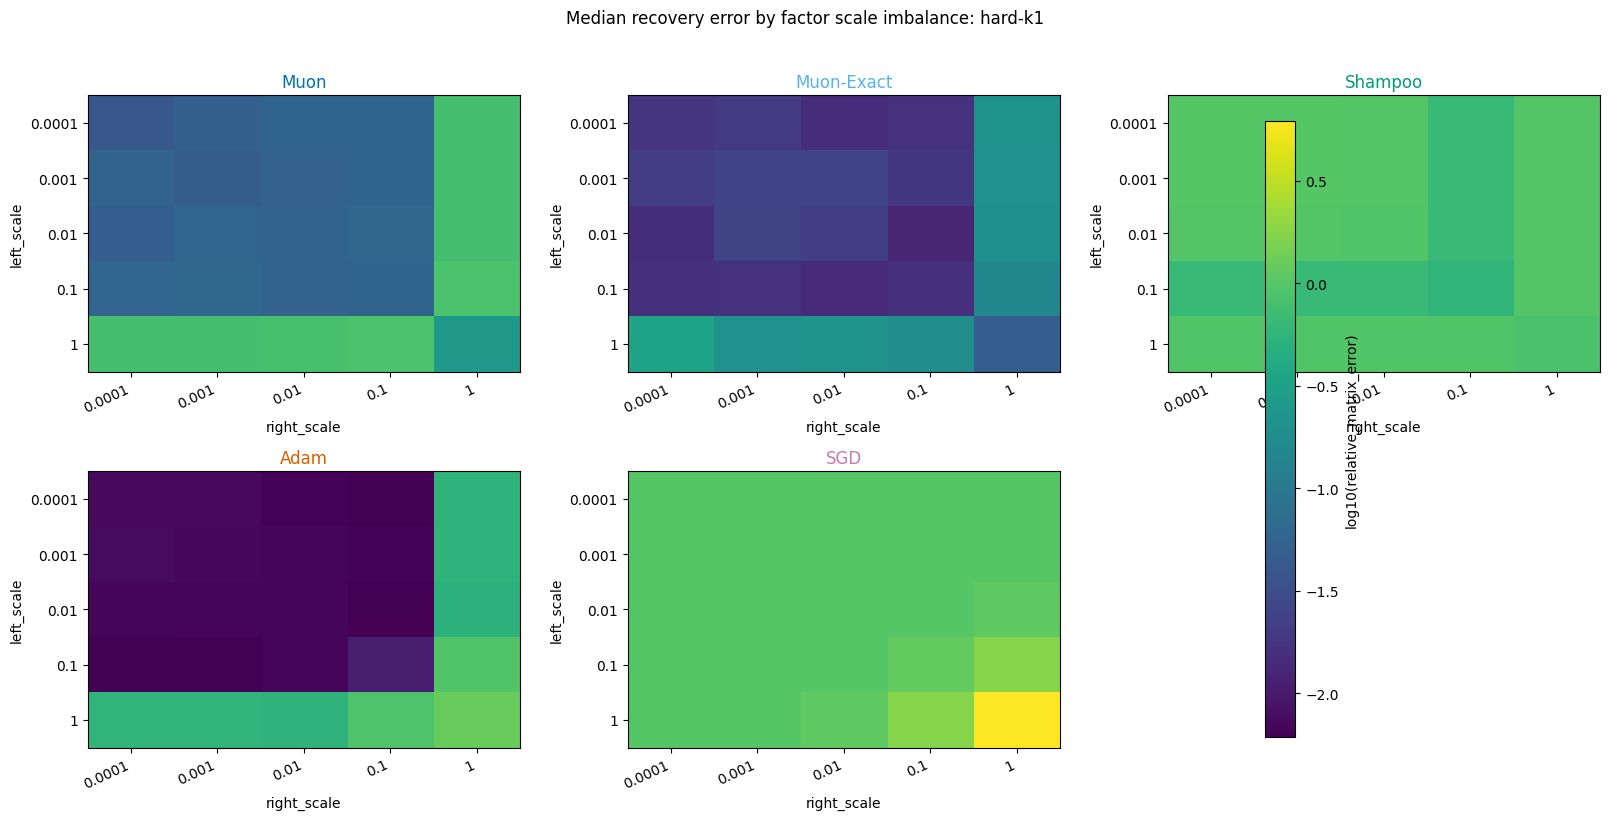

/Users/tianyangliu/Desktop/muonexperiment/plotting/phase.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


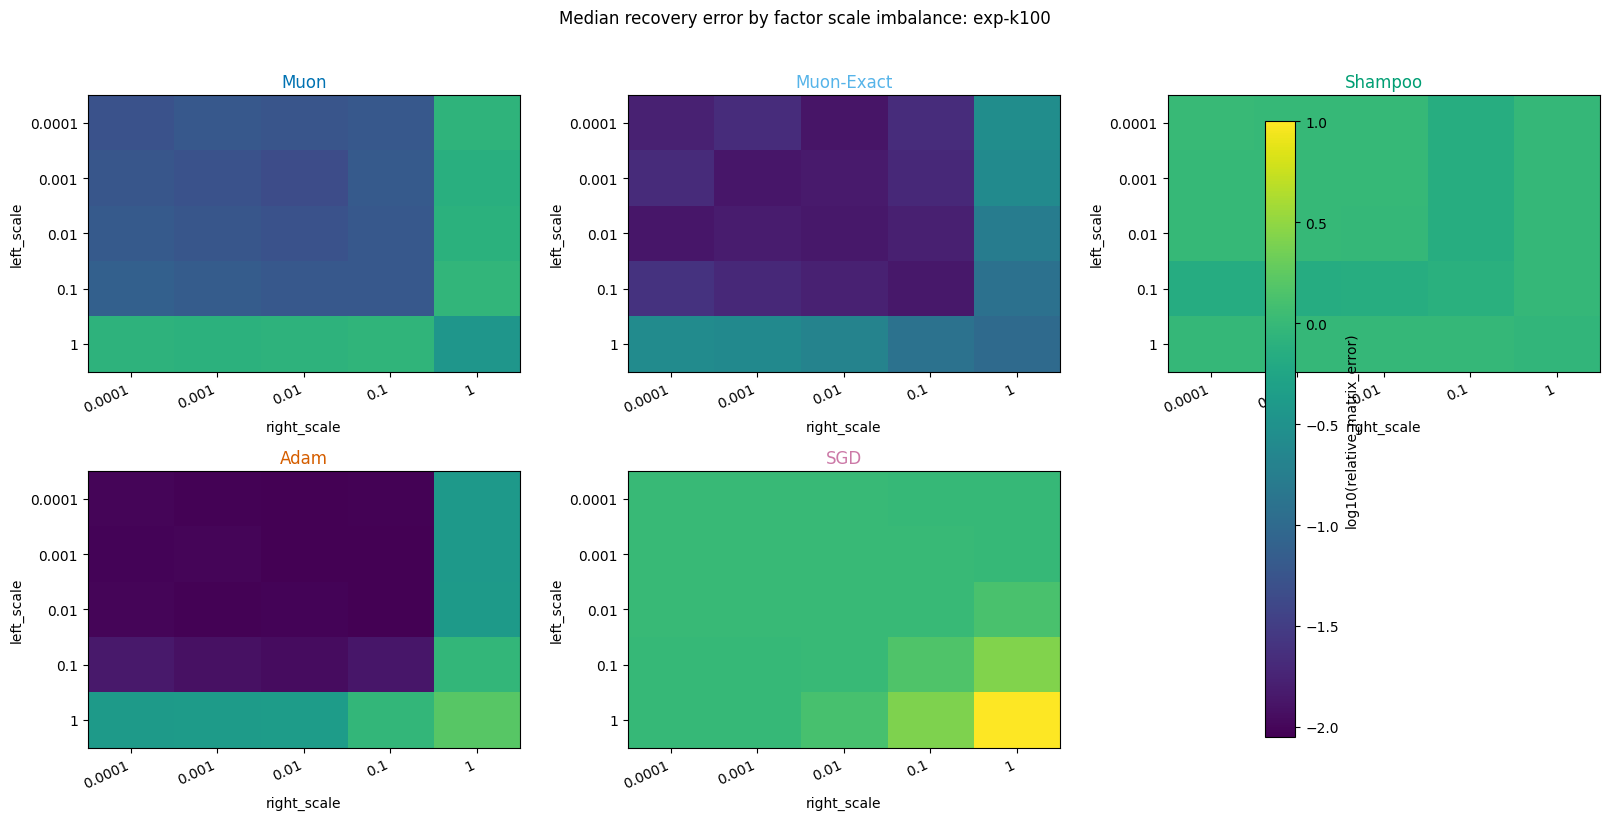

In [6]:
for spectrum_case in ["hard-k1", "exp-k100"]:
    fig, axes = plotting.plot_optimizer_heatmaps(
        run_summary[run_summary["spectrum_case"] == spectrum_case],
        x="right_scale",
        y="left_scale",
        metric="relative_matrix_error",
        title=f"Median recovery error by factor scale imbalance: {spectrum_case}",
        log_color=True,
    )
    show_figure(fig)


### Muon Vs Adam Recovery Gap

This plot asks whether Muon and Adam respond differently to the scale-imbalance grid $(a,b)$ defined in the Problem cell.

These heatmaps keep the same $(a,b)$ grid and target-spectrum split, but color is $\log_{10}(e_{\mathrm{Muon}})-\log_{10}(e_{\mathrm{Adam}})$ after seed-median aggregation. Negative cells favor Muon and positive cells favor Adam. This is the cleanest view for asking whether Muon specifically handles scale imbalance better or worse than Adam.

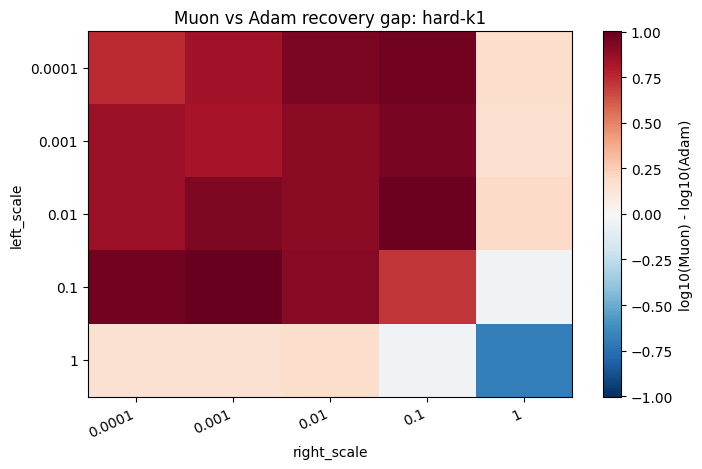

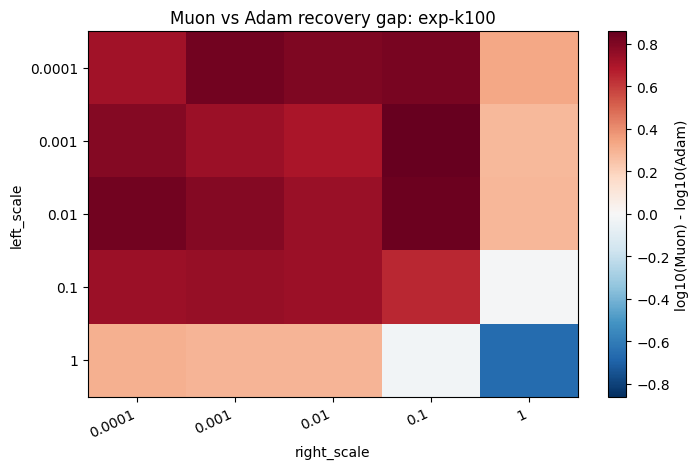

In [7]:
for spectrum_case in ["hard-k1", "exp-k100"]:
    fig, ax = plotting.plot_gap_heatmap(
        run_summary[run_summary["spectrum_case"] == spectrum_case],
        x="right_scale",
        y="left_scale",
        metric="relative_matrix_error",
        left_algo="Muon",
        right_algo="Adam",
        title=f"Muon vs Adam recovery gap: {spectrum_case}",
    )
    show_figure(fig)


### Balancedness Heatmaps

The Problem cell motivates scale imbalance geometrically; this plot measures that geometry through the balancedness statistic rather than recovery error.

These figures measure geometry of the learned factors, not recovery error. The horizontal axis is right scale $b$, the vertical axis is left scale $a$, optimizer is the panel, and color is seed-median balancedness $B=\lVert L^\top L-R^\top R\rVert_F/(\lVert L^\top L\rVert_F+\lVert R^\top R\rVert_F+\epsilon)$. Values near $0$ mean the two factors have matched Gram matrices; larger values mean the factorization remains imbalanced.

/Users/tianyangliu/Desktop/muonexperiment/plotting/phase.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


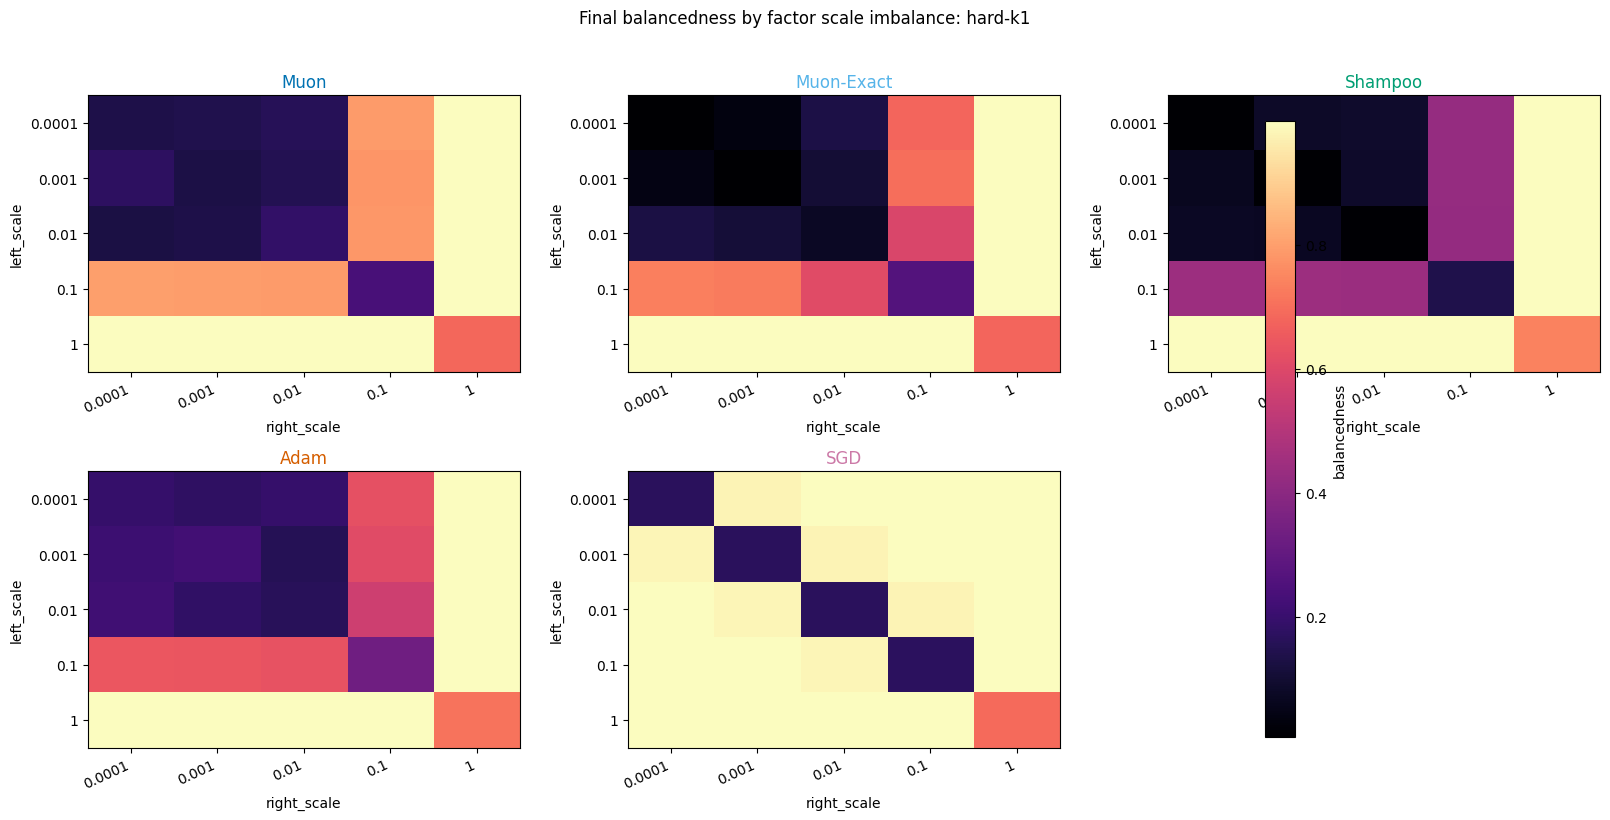

/Users/tianyangliu/Desktop/muonexperiment/plotting/phase.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


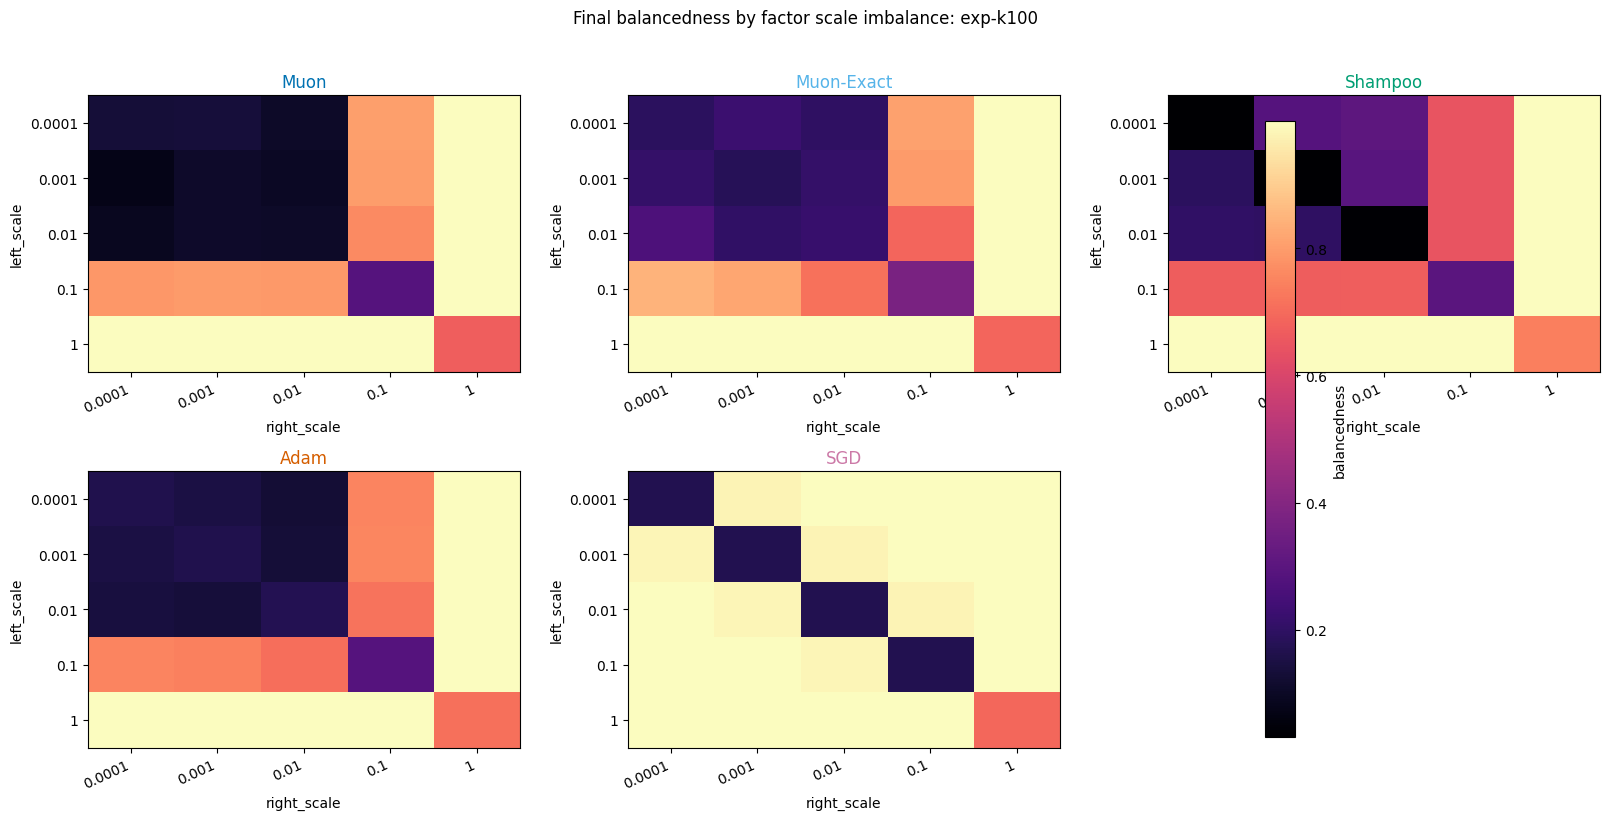

In [8]:
for spectrum_case in ["hard-k1", "exp-k100"]:
    fig, axes = plotting.plot_optimizer_heatmaps(
        run_summary[run_summary["spectrum_case"] == spectrum_case],
        x="right_scale",
        y="left_scale",
        metric="balancedness",
        title=f"Final balancedness by factor scale imbalance: {spectrum_case}",
        log_color=False,
        cmap="magma",
    )
    show_figure(fig)


### Balancedness Over Training

These selected scale pairs from the Problem grid show whether imbalance is corrected dynamically during optimization.

The panels pick three representative scale pairs under `hard-k1`: tiny balanced, standard balanced, and severely imbalanced. The horizontal axis is step $t$, the vertical axis is seed-median $B_t$, and color is optimizer. This tells whether an optimizer corrects imbalance during training or merely tolerates it while reducing loss.

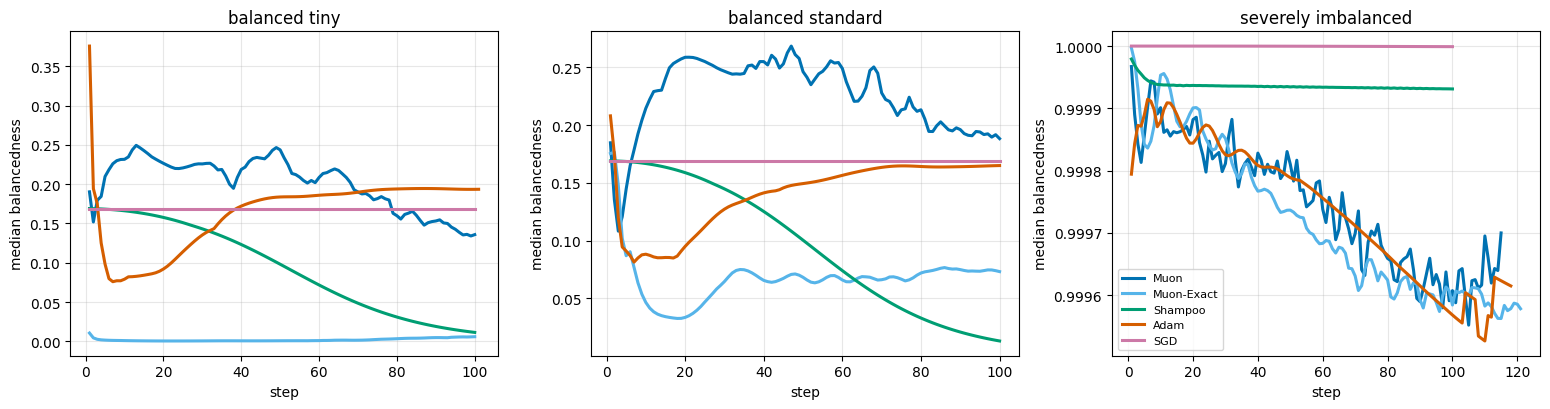

In [9]:
REPRESENTATIVE = [("balanced tiny", 1e-4, 1e-4), ("balanced standard", 1e-2, 1e-2), ("severely imbalanced", 1e-4, 1.0)]
fig, axes = plt.subplots(1, len(REPRESENTATIVE), figsize=(5.2 * len(REPRESENTATIVE), 4.2), sharey=False)
for ax, (label, left_scale, right_scale) in zip(axes, REPRESENTATIVE):
    sub = runs[(runs["spectrum_case"] == "hard-k1") & (runs["left_scale"] == left_scale) & (runs["right_scale"] == right_scale)]
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["balancedness"].median()
        ax.plot(curve["step"], curve["balancedness"], color=plotting.algorithm_color(algo), linewidth=2.2, label=algo)
    ax.set_title(label)
    ax.set_xlabel("step")
    ax.set_ylabel("median balancedness")
    ax.grid(alpha=0.3)
axes[-1].legend(fontsize=8)
fig.tight_layout()
show_figure(fig)


### Factor Norms Over Training

The Problem cell’s scale symmetry means factor norms can change without changing $LR^\top$; these plots expose that hidden degree of freedom.

Each generated figure fixes one representative scale pair. Inside the figure, the three panels show $\lVert L_t\rVert_F$, $\lVert R_t\rVert_F$, and $\lVert L_tR_t^\top\rVert_F$ as functions of step. Color is optimizer and each curve is a seed median. Read this together with balancedness: factor norms explain whether a high $B_t$ comes from one factor growing, the other shrinking, or both changing.

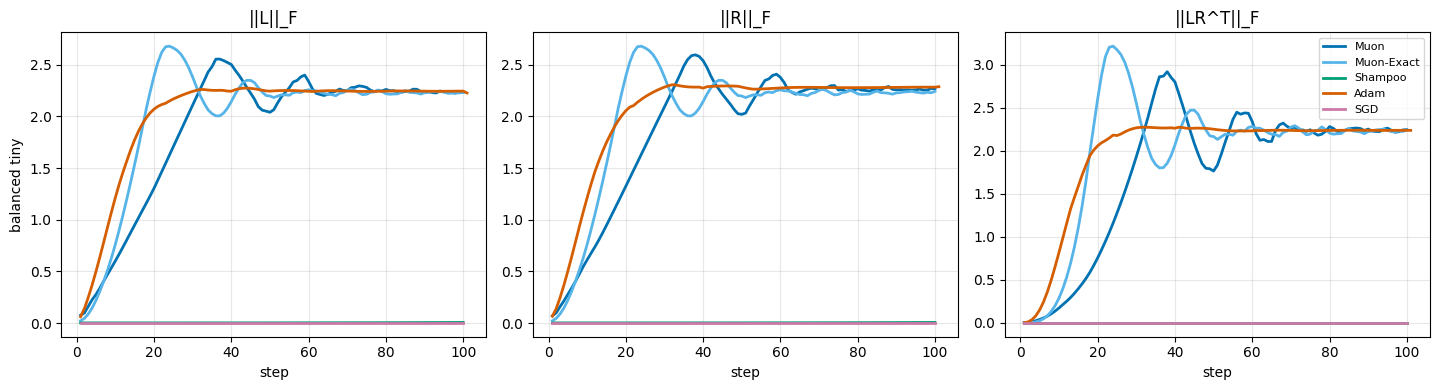

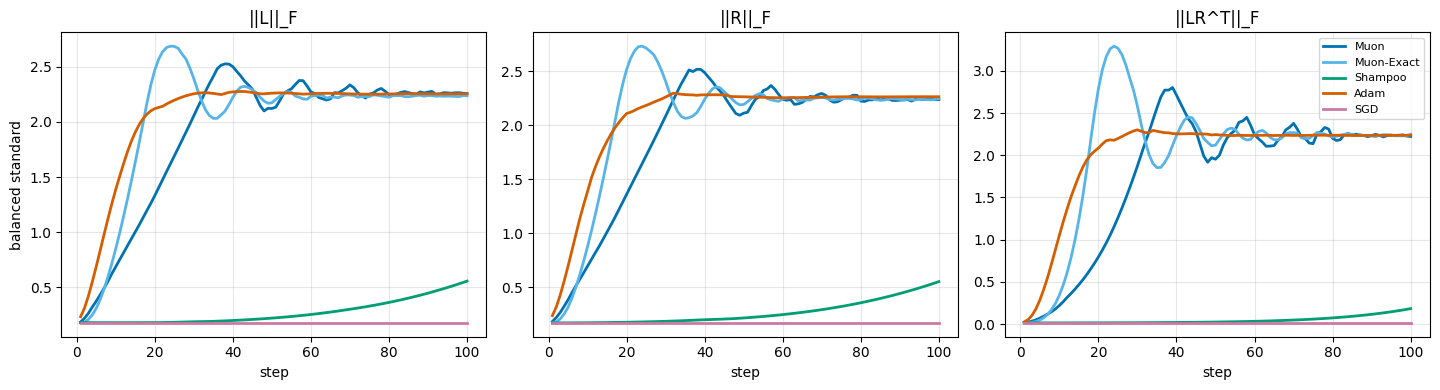

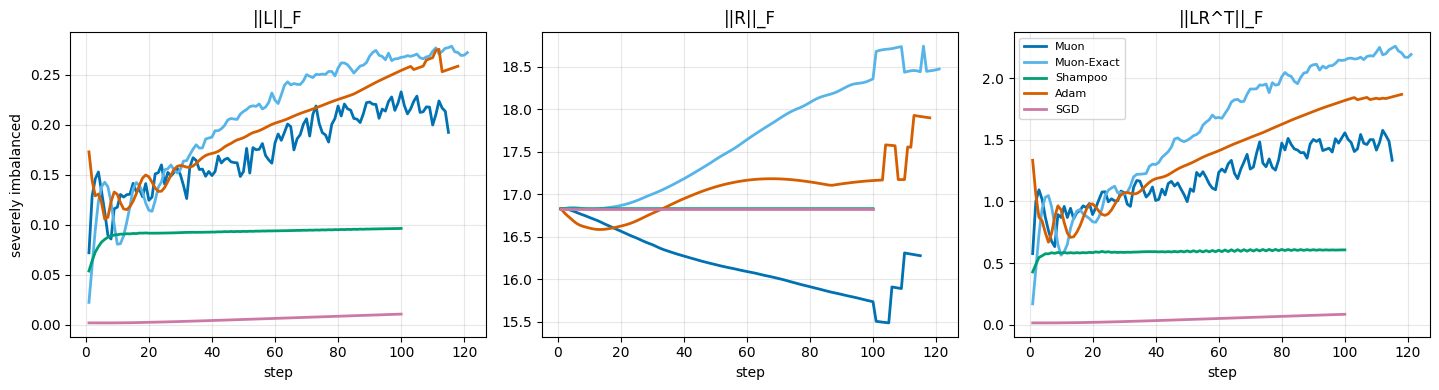

In [10]:
for label, left_scale, right_scale in REPRESENTATIVE:
    sub = runs[(runs["spectrum_case"] == "hard-k1") & (runs["left_scale"] == left_scale) & (runs["right_scale"] == right_scale)]
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.0), sharex=True)
    for ax, metric, ylabel in zip(axes, ["left_norm", "right_norm", "product_norm"], ["||L||_F", "||R||_F", "||LR^T||_F"]):
        for algo in ALGOS:
            curve = sub[sub["algo"] == algo].groupby("step", as_index=False)[metric].median()
            ax.plot(curve["step"], curve[metric], color=plotting.algorithm_color(algo), linewidth=2.0, label=algo)
        ax.set_title(ylabel)
        ax.set_xlabel("step")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel(label)
    axes[-1].legend(fontsize=8)
    fig.tight_layout()
    show_figure(fig)


### Representative Loss Curves

These curves show whether the scale-imbalance regimes from the Problem cell also change the objective trajectory $g(L,R)$.

The panels use the same representative scale pairs as the balancedness plot. The horizontal axis is step $t$, the vertical axis is seed-median training loss $g(L_t,R_t)$, and color is optimizer. This shows whether factor-geometry differences actually translate into objective-value differences.

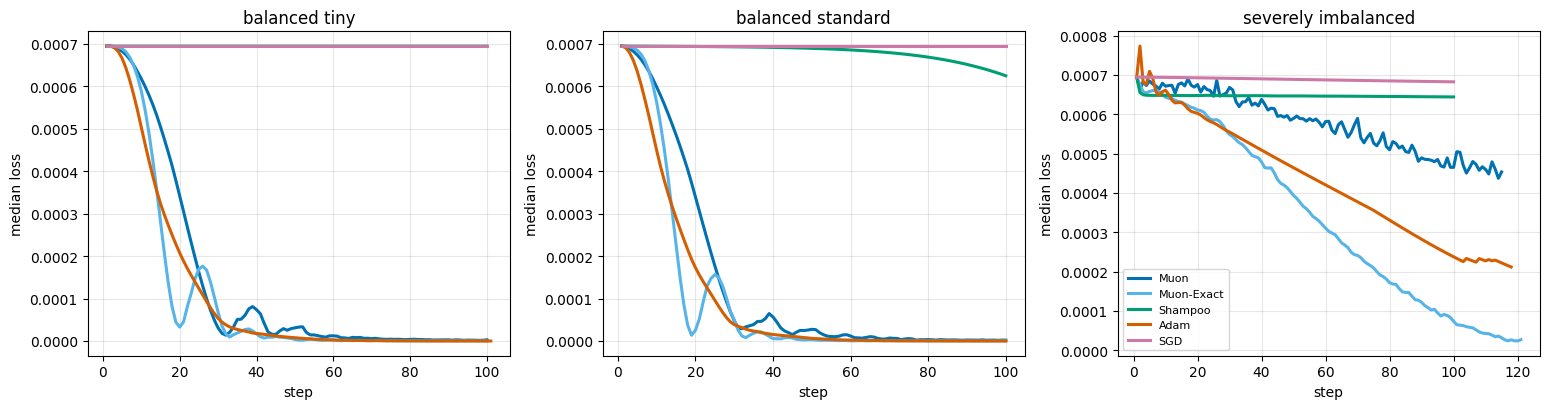

In [11]:
fig, axes = plt.subplots(1, len(REPRESENTATIVE), figsize=(5.2 * len(REPRESENTATIVE), 4.2), sharey=False)
for ax, (label, left_scale, right_scale) in zip(axes, REPRESENTATIVE):
    sub = runs[(runs["spectrum_case"] == "hard-k1") & (runs["left_scale"] == left_scale) & (runs["right_scale"] == right_scale)]
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["loss"].median()
        ax.plot(curve["step"], curve["loss"], color=plotting.algorithm_color(algo), linewidth=2.2, label=algo)
    ax.set_title(label)
    ax.set_xlabel("step")
    ax.set_ylabel("median loss")
    ax.grid(alpha=0.3)
axes[-1].legend(fontsize=8)
fig.tight_layout()
show_figure(fig)


### Representative Log-Loss Curves

This is the same Problem-cell scale-pair selection on a log loss axis, which is better for late convergence comparison.

This repeats the representative loss curves on a logarithmic vertical axis. The panel and color encodings are unchanged. Use it to compare convergence rates and small final losses that are visually compressed in the linear-scale plot.

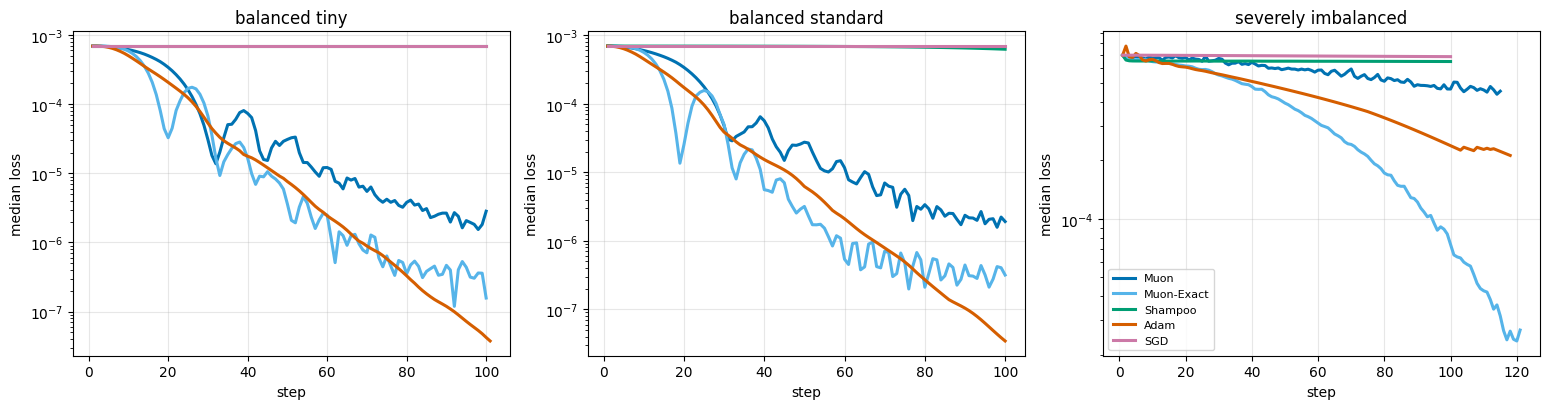

In [12]:
fig, axes = plt.subplots(1, len(REPRESENTATIVE), figsize=(5.2 * len(REPRESENTATIVE), 4.2), sharey=False)
for ax, (label, left_scale, right_scale) in zip(axes, REPRESENTATIVE):
    sub = runs[(runs["spectrum_case"] == "hard-k1") & (runs["left_scale"] == left_scale) & (runs["right_scale"] == right_scale)]
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["loss"].median()
        ax.plot(curve["step"], curve["loss"], color=plotting.algorithm_color(algo), linewidth=2.2, label=algo)
    ax.set_title(label)
    ax.set_xlabel("step")
    ax.set_ylabel("median loss")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
axes[-1].legend(fontsize=8)
fig.tight_layout()
show_figure(fig)


### Main Table


In [13]:
imbalance_table = run_summary.groupby(["spectrum_case", "left_scale", "right_scale", "algo"], as_index=False, observed=True).agg(
    median_recovery=("relative_matrix_error", "median"),
    median_balancedness=("balancedness", "median"),
    median_product_norm=("product_norm", "median"),
    divergence_rate=("diverged", "mean"),
)
best_recovery = imbalance_table.sort_values("median_recovery").groupby(["spectrum_case", "left_scale", "right_scale"], as_index=False, observed=True).first()
IPython.display.display(best_recovery)


,spectrum_case,left_scale,right_scale,algo,median_recovery,median_balancedness,median_product_norm,divergence_rate
0,exp-k100,0.0001,0.0001,Adam,0.009918,0.163768,1.373910,0.0
1,exp-k100,0.0001,0.0010,Adam,0.009222,0.151702,1.373906,0.0
2,exp-k100,0.0001,0.0100,Adam,0.009038,0.129285,1.373925,0.0
3,exp-k100,0.0001,0.1000,Adam,0.009403,0.753241,1.374139,0.0
4,exp-k100,0.0001,1.0000,Muon-Exact,0.280843,0.999665,1.347269,0.0
5,exp-k100,0.0010,0.0001,Adam,0.009457,0.150879,1.373785,0.0
6,exp-k100,0.0010,0.0010,Adam,0.009755,0.163905,1.373908,0.0
7,exp-k100,0.0010,0.0100,Adam,0.009111,0.132460,1.374056,0.0
8,exp-k100,0.0010,0.1000,Adam,0.008913,0.755710,1.373997,0.0
9,exp-k100,0.0010,1.0000,Muon-Exact,0.260003,0.999641,1.408033,0.0


### Reading The Result

Compare recovery and balancedness together. A method that lowers loss but drives balancedness upward is exploiting the scale symmetry in an unstable way; a robust optimizer should recover `X_star` without exploding one factor relative to the other.
